In [36]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# Style
sns.set(style="whitegrid")

In [38]:
# Load Dataset
df = pd.read_excel(r"C:\Users\sidha\OneDrive\Desktop\resume\Project\Superstore Sales Analysis.xlsx")

In [39]:
# Basic Exploration
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


First 5 rows:
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   So

In [40]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Drop duplicates
df.drop_duplicates(inplace=True)



Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [41]:
# Feature Engineering
if 'Order Date' in df.columns:
    df['Year'] = df['Order Date'].dt.year
    df['Month'] = df['Order Date'].dt.month
    df['Month Name'] = df['Order Date'].dt.month_name()

In [42]:
# Key Metrics
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique() if 'Order ID' in df.columns else len(df)

print("\n Key Metrics:")
print(f"Total Sales: {total_sales}")
print(f"Total Profit: {total_profit}")
print(f"Total Orders: {total_orders}")



🔑 Key Metrics:
Total Sales: 2297334.9003000003
Total Profit: 286397.0216999999
Total Orders: 5009


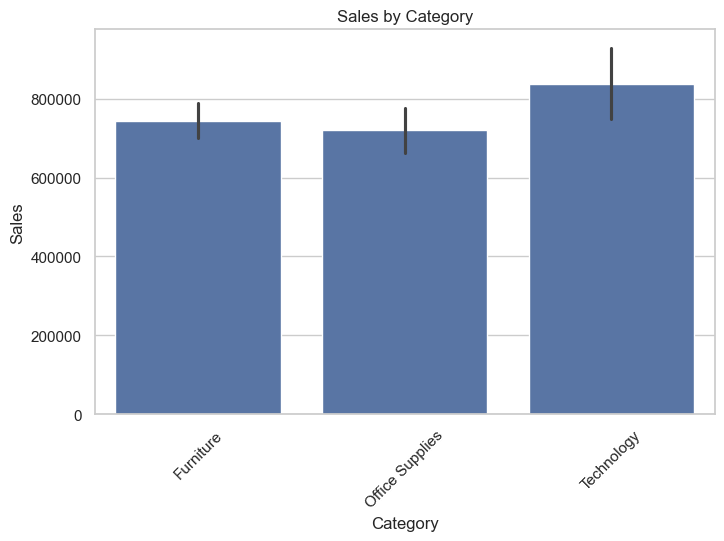

In [43]:
# Sales by Category
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=df, estimator=sum)
plt.title("Sales by Category")
plt.xticks(rotation=45)
plt.show()

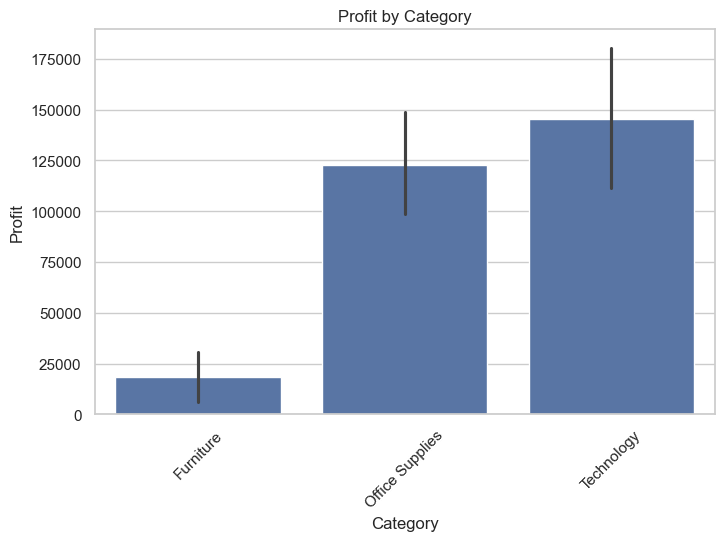

In [44]:
# Profit by Category
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Profit', data=df, estimator=sum)
plt.title("Profit by Category")
plt.xticks(rotation=45)
plt.show()

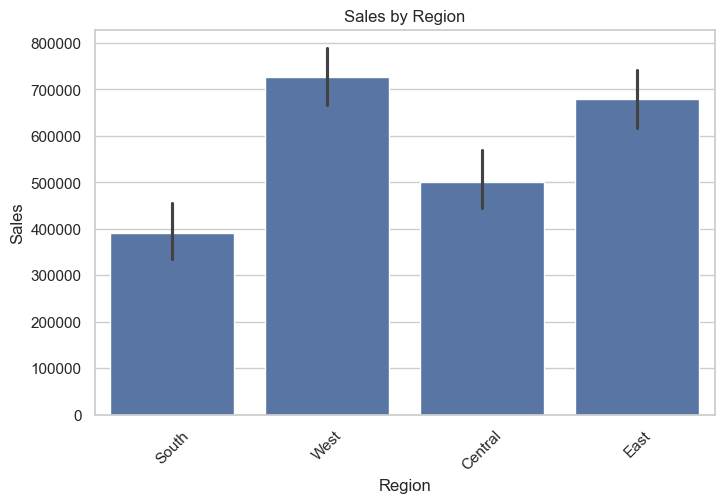

In [45]:
# Sales by Region
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Sales', data=df, estimator=sum)
plt.title("Sales by Region")
plt.xticks(rotation=45)
plt.show()

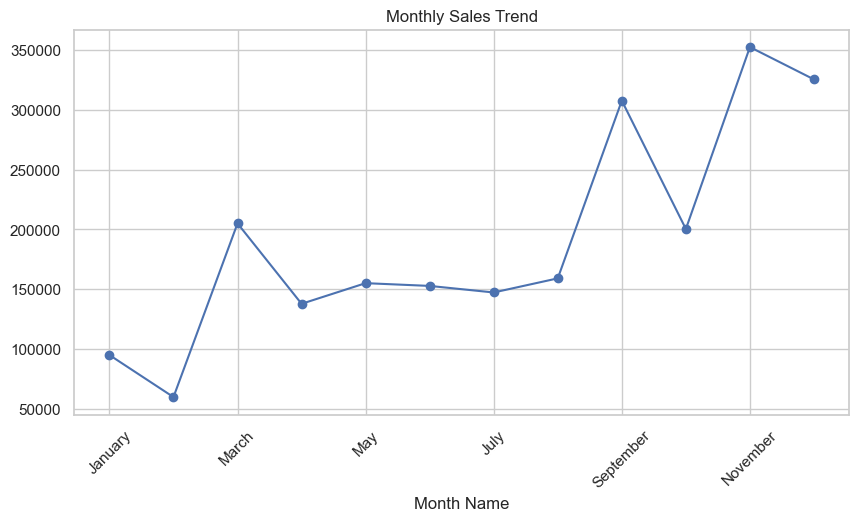

In [46]:
# Monthly Sales Trend
if 'Month Name' in df.columns:
    monthly_sales = df.groupby('Month Name')['Sales'].sum().reindex([
        'January','February','March','April','May','June',
        'July','August','September','October','November','December'
    ])

    plt.figure(figsize=(10,5))
    monthly_sales.plot(kind='line', marker='o')
    plt.title("Monthly Sales Trend")
    plt.xticks(rotation=45)
    plt.show()

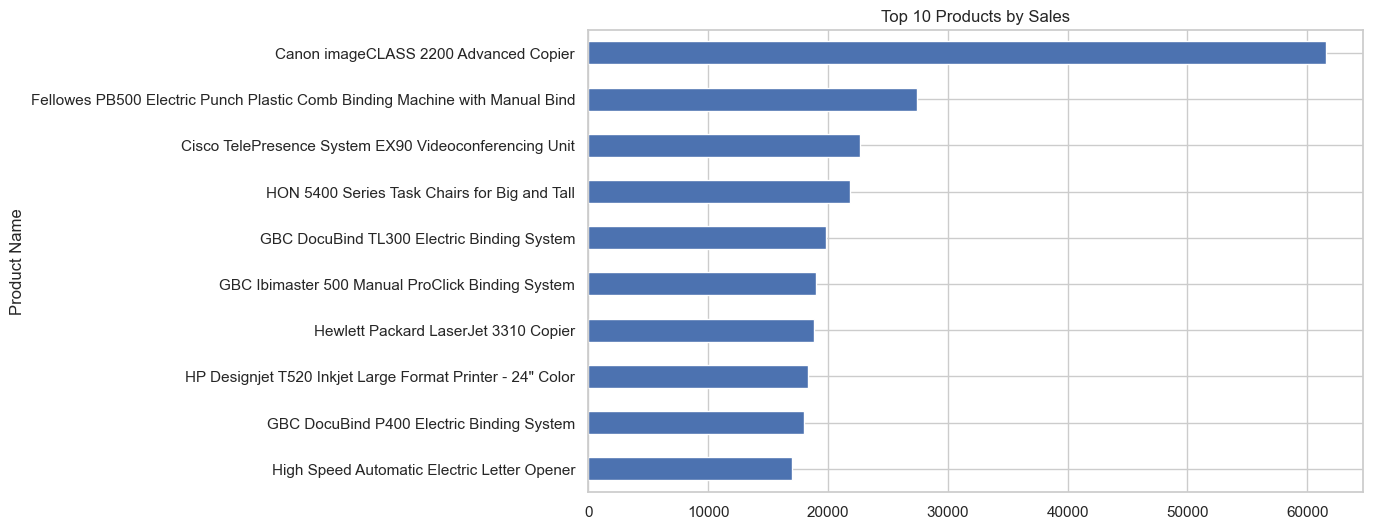

In [47]:
# Top 10 Products by Sales
if 'Product Name' in df.columns:
    top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)

    plt.figure(figsize=(10,6))
    top_products.plot(kind='barh')
    plt.title("Top 10 Products by Sales")
    plt.gca().invert_yaxis()
    plt.show()

In [48]:
# Loss-Making Products
loss_products = df[df['Profit'] < 0]

print("\nNumber of loss-making records:", len(loss_products))


Number of loss-making records: 1871


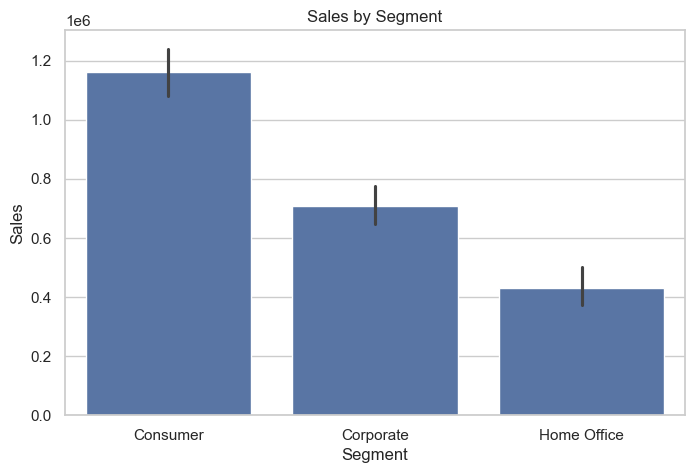

In [49]:
# Segment Analysis
if 'Segment' in df.columns:
    plt.figure(figsize=(8,5))
    sns.barplot(x='Segment', y='Sales', data=df, estimator=sum)
    plt.title("Sales by Segment")
    plt.show()

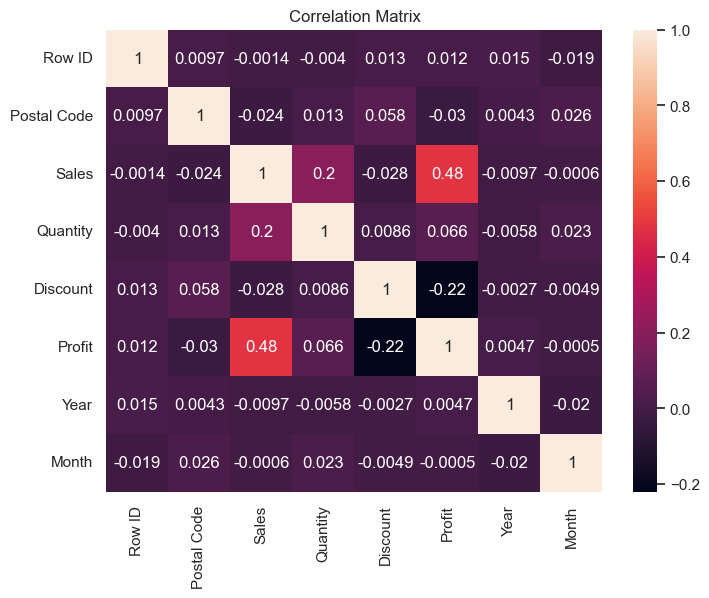

In [50]:
# 🔥 Correlation Heatmap
# ==============================
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()
